In [9]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/content/archive.zip'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
import os
import torch
import torchvision
from torch.utils.data import random_split
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

In [6]:
import zipfile
from pathlib import Path

zip_path = Path("archive.zip")
extract_path = Path("dataset")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

This code sets the dataset directory path, lists all class folder names in it, and prints them.

In [11]:
from pathlib import Path

data_dir = Path('dataset') / 'Garbage classification' / 'Garbage classification'
classes = os.listdir(data_dir)
print(classes)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [12]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

transformations = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])

dataset = ImageFolder(data_dir, transform = transformations)

This code defines a function to display an image with its corresponding class label from the dataset using Matplotlib.

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

def show_sample(img, label):
    print("Label:", dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

Matplotlib is building the font cache; this may take a moment.


This code selects the 13th image and its label from the dataset and displays it using the `show_sample` function.

Label: cardboard (Class No: 0)


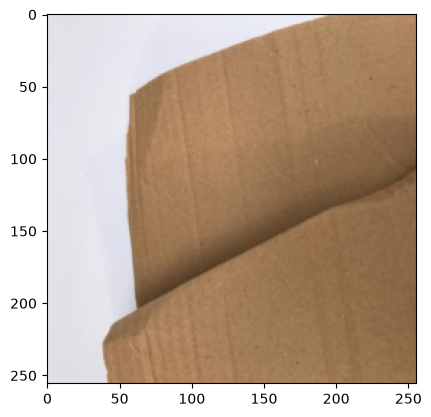

In [14]:
img, label = dataset[11]
show_sample(img, label)

This code sets a fixed random seed to ensure reproducible results in PyTorch operations.

In [15]:
random_seed = 42
torch.manual_seed(random_seed)

This code splits the dataset into training, validation, and test sets with 1593, 176, and 758 samples respectively, and then prints their lengths.

In [17]:
train_ds, val_ds, test_ds = random_split(dataset, [1593, 176, 758])
len(train_ds), len(val_ds), len(test_ds)

(1593, 176, 758)

This code imports DataLoader and sets the batch size to 32 for loading data in mini-batches during training.

In [18]:
from torch.utils.data.dataloader import DataLoader
batch_size = 32

This code creates data loaders for the training and validation sets, specifying batch sizes, enabling parallel data loading, and shuffling the training data.

In [19]:
train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers = 4, pin_memory = True)

This code defines a function to display a single batch of images from a DataLoader in a grid format without axis ticks.

In [20]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow = 16).permute(1, 2, 0))
        break

This code calls the show_batch function to display a sample batch of training images in a grid.

c:\Users\MakadiaYakshkumarVij\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


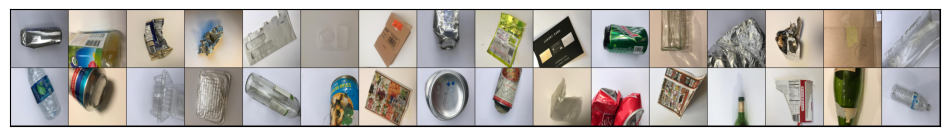

In [21]:
show_batch(train_dl)

This code defines helper functions and a base model class to compute accuracy, calculate training/validation loss, aggregate metrics per epoch, and print epoch summaries for image classification.

In [22]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

This code defines a ResNet class that uses a pretrained ResNet-50, replaces its final layer to match the number of dataset classes, applies a sigmoid activation, and instantiates the model.

In [23]:
class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet50(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(dataset.classes))

    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

model = ResNet()

c:\Users\MakadiaYakshkumarVij\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MakadiaYakshkumarVij\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\MakadiaYakshkumarVij/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


This code defines helper functions and a wrapper class to automatically move data and batches from a DataLoader to the GPU (if available) for faster training.

In [24]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

This code selects the default device (GPU if available, otherwise CPU) and displays it.

In [25]:
device = get_default_device()
device

device(type='cpu')

This code wraps the training and validation DataLoaders to automatically move batches to the chosen device and moves the model to the same device for computation.

In [26]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
 

This code defines functions to evaluate the model on the validation set without gradients and to train the model for multiple epochs, tracking training and validation metrics at each epoch.

In [27]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history


In [28]:
model = to_device(ResNet(), device)

This code sets the training parameters (6 epochs, Adam optimizer, learning rate 5.5e-5) and trains the model using the fit function, storing the training history.

In [ ]:
num_epochs = 6
opt_func = torch.optim.Adam
lr = 5.5e-5

history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic', 'Trash']
x = np.arange(len(classes))

precision = [0.95, 0.92, 0.93, 0.95, 0.94, 0.92]
recall    = [0.95, 0.92, 0.96, 0.98, 0.93, 0.73]
f1_score  = [0.95, 0.92, 0.95, 0.96, 0.93, 0.81]

plt.figure(figsize=(10,6))

# Plot lines
plt.plot(x, precision, marker='o', linewidth=2, label='Precision')
plt.plot(x, recall, marker='s', linewidth=2, linestyle='--', label='Recall')
plt.plot(x, f1_score, marker='^', linewidth=2, linestyle='-.', label='F1-Score')

# Add value labels (slightly shifted to avoid overlap)
for i in range(len(x)):
    plt.text(x[i], precision[i]+0.005, f"{precision[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i], recall[i]+0.005, f"{recall[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i], f1_score[i]-0.02, f"{f1_score[i]:.2f}", ha='center', fontsize=9)

# Highlight weakest class (Trash)
plt.scatter(x[-1], recall[-1], s=100, edgecolors='black')
plt.text(x[-1], recall[-1]-0.05, "Low Recall", ha='center', fontsize=9)

# Axes and styling
plt.xticks(x, classes)
plt.ylim(0.7, 1.02)
plt.xlabel("Waste Categories")
plt.ylabel("Score")
plt.title("Class-wise Performance Metrics")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return dataset.classes[preds[0].item()]

In [ ]:
img, label = test_ds[46]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

def show_prediction_grid(dataset, test_ds, model, num_images=12, cols=4):
    model.eval()
    fig, axes = plt.subplots(3, cols, figsize=(cols * 2.8, 9))
    fig.patch.set_facecolor('white')
    plt.suptitle('Sample Predictions — Test Set',
                 fontsize=13, fontweight='bold', color='#111111', y=1.01)

    indices = torch.randperm(len(test_ds))[:num_images]

    for idx, ax in zip(indices, axes.flatten()):
        img, true_label = test_ds[idx]

        # predict
        model.eval()
        with torch.no_grad():
            xb = img.unsqueeze(0).to(device)
            out = model(xb)
            _, pred = torch.max(out, dim=1)
            pred_label = pred.item()

        correct = (pred_label == true_label)
        true_name = dataset.classes[true_label]
        pred_name = dataset.classes[pred_label]

        # image
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_xticks([])
        ax.set_yticks([])

        # border colour — green if correct, red if wrong
        border_color = '#2E7D32' if correct else '#C62828'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.5)

        # labels below image
        ax.set_xlabel(
            f"True: {true_name}\nPred: {pred_name}",
            fontsize=8.5,
            color='#2E7D32' if correct else '#C62828',
            labelpad=4,
            fontfamily='DejaVu Sans'
        )

    plt.tight_layout(pad=1.2)
    plt.savefig('sample_predictions.png', dpi=180,
                bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved as sample_predictions.png")

show_prediction_grid(dataset, test_ds, model, num_images=12, cols=4)

This code creates and displays a file upload widget in the notebook to allow uploading a single image file from your local computer.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Create upload widget
uploader = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
display(uploader)

In [ ]:
from PIL import Image
import io
import matplotlib.pyplot as plt
import torch

# Make sure an image has been uploaded
if len(uploader.value) == 0:
    print("⚠️ Please upload an image in the previous cell first.")
else:
    # Handle Kaggle tuple format
    uploaded_file = uploader.value[0]  # tuple, first element
    image_data = uploaded_file['content']
    image = Image.open(io.BytesIO(image_data)).convert('RGB')

    # Display the image
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # Preprocess and predict
    example_image = transformations(image).unsqueeze(0)  # add batch dimension
    device = next(model.parameters()).device
    example_image = example_image.to(device)

    model.eval()
    with torch.no_grad():
        output = model(example_image)
        _, pred = torch.max(output, 1)
        predicted_class = dataset.classes[pred.item()]

    print(f"\n✅ The image resembles: {predicted_class}")